# NLP Results: Sentiment & Keywords



In [8]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import text
import database as db

pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Sentiment Distribution

sentiment
neutral     10901
negative     4517
positive     1374
Name: count, dtype: int64

Percentages:
sentiment
neutral     64.9
negative    26.9
positive     8.2
Name: count, dtype: float64


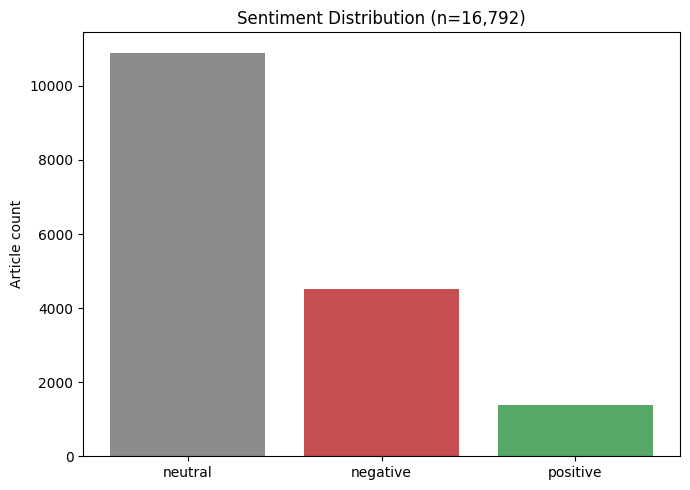

In [9]:
with db.get_connection() as conn:
    sent_df = pd.read_sql(text('SELECT * FROM article_sentiment'), conn)

sent_counts = sent_df['sentiment'].value_counts()
print(sent_counts)
print(f"\nPercentages:\n{(sent_counts / len(sent_df) * 100).round(1)}")

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'positive': '#55A868', 'neutral': '#8C8C8C', 'negative': '#C44E52'}
ax.bar(sent_counts.index, sent_counts.values, color=[colors.get(k, 'gray') for k in sent_counts.index])
ax.set_ylabel('Article count')
ax.set_title(f'Sentiment Distribution (n={len(sent_df):,})')
plt.tight_layout()
plt.show()

## 2. Sentiment Over Time (Weekly)

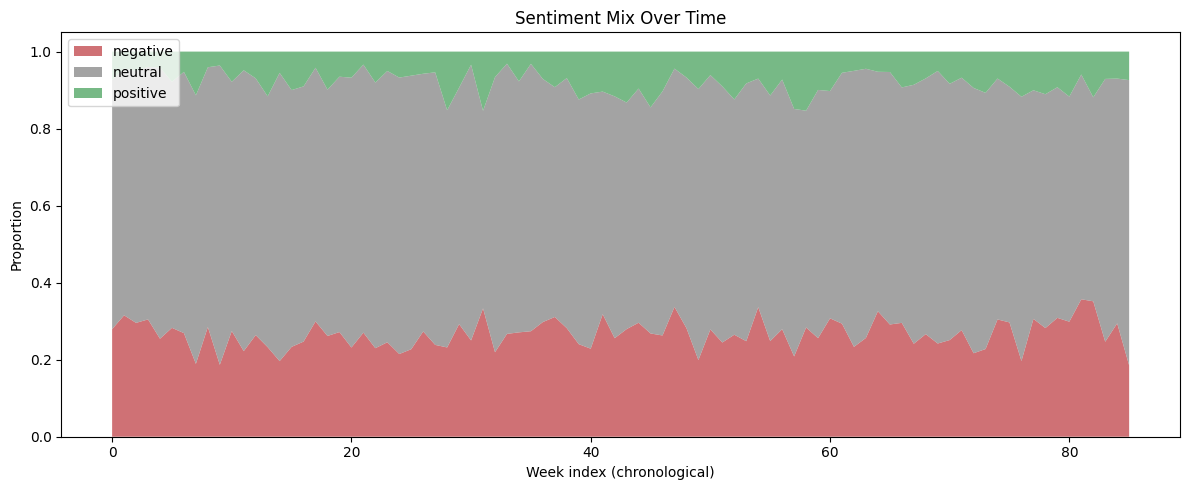

In [10]:
with db.get_connection() as conn:
    weekly_sent = pd.read_sql(text('''
        SELECT pn.publication_week AS week, s.sentiment, COUNT(*) as cnt
        FROM article_sentiment s
        JOIN processed_news pn ON s.article_id = pn.article_id
        WHERE pn.duplicate_status != 'EXACT_DUPLICATE'
        GROUP BY pn.publication_week, s.sentiment
        ORDER BY pn.publication_week
    '''), conn)

pivot = weekly_sent.pivot(index='week', columns='sentiment', values='cnt').fillna(0)
pivot_ratio = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots()
ax.stackplot(range(len(pivot_ratio)), 
             pivot_ratio.get('negative', 0), pivot_ratio.get('neutral', 0), pivot_ratio.get('positive', 0),
             labels=['negative', 'neutral', 'positive'],
             colors=['#C44E52', '#8C8C8C', '#55A868'], alpha=0.8)
ax.set_xlabel('Week index (chronological)')
ax.set_ylabel('Proportion')
ax.set_title('Sentiment Mix Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 3. Sentiment Model Evaluation

Against the 120 hand-labeled articles. **Reminder of the key finding:** the model measures linguistic
tone, not substantive crisis-relevance — this is why accuracy was only 45%. See the conversation/report
for the full discussion of why this is a legitimate finding, not a bug.

In [11]:
# Re-run the evaluation for this notebook (requires data/processed/sentiment_eval_sample.csv
# with your true_sentiment labels — see evaluate_sentiment.py)
eval_path = '../data/processed/sentiment_eval_sample.csv'
if os.path.exists(eval_path):
    import evaluate_sentiment
    results = evaluate_sentiment.run(eval_path)
else:
    print(f"Eval file not found at {eval_path} — skipping. Run sentiment.get_sentiment_eval_sample() first if needed.")


Evaluated on 120 hand-labeled articles

Overall accuracy: 0.450

Per-class metrics:
Class      Precision  Recall     F1         Support   
negative   0.871      0.450      0.593      60        
neutral    0.225      0.900      0.360      20        
positive   1.000      0.225      0.367      40        

Confusion matrix (rows=true, columns=predicted):
               pred_negative  pred_neutral  pred_positive
true_negative             27            33              0
true_neutral               2            18              0
true_positive              2            29              9

Full classification report:
              precision    recall  f1-score   support

    negative       0.87      0.45      0.59        60
     neutral       0.23      0.90      0.36        20
    positive       1.00      0.23      0.37        40

    accuracy                           0.45       120
   macro avg       0.70      0.53      0.44       120
weighted avg       0.81      0.45      0.48       120



## 4. Top Keywords Overall

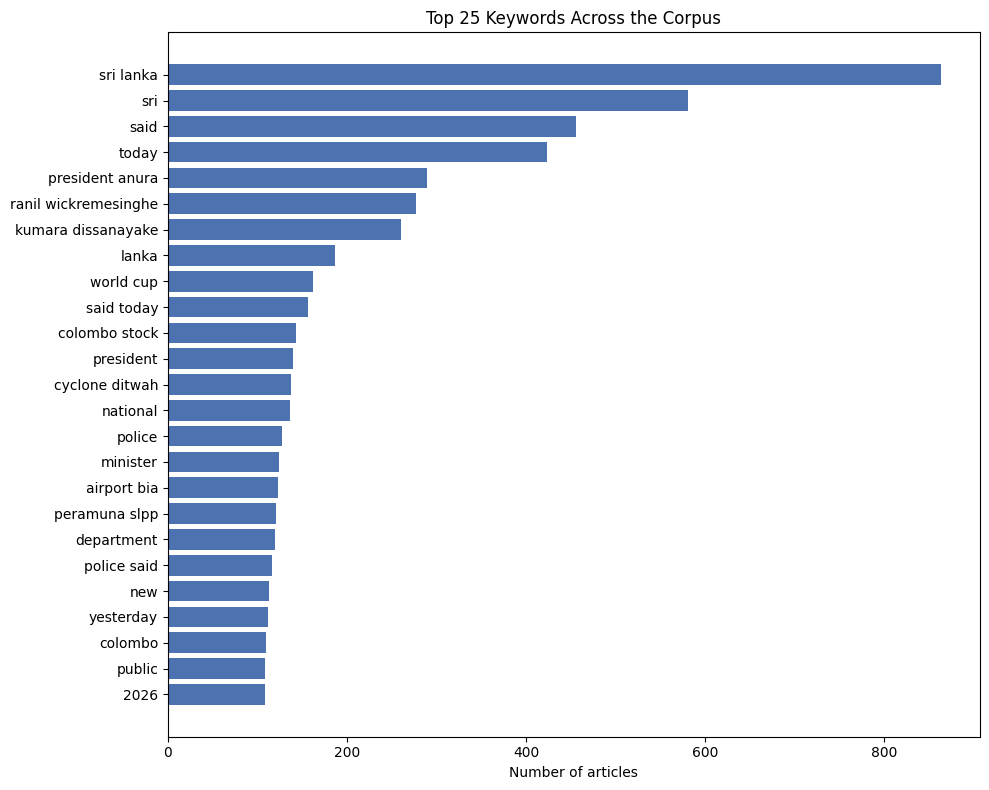

,keyword,article_count,avg_score
0,sri lanka,864,0.382961
1,sri,581,0.312551
2,said,456,0.043093
3,today,424,0.084751
4,president anura,289,0.385699
5,ranil wickremesinghe,277,0.443966
6,kumara dissanayake,260,0.446493
7,lanka,187,0.334411
8,world cup,162,0.335866
9,said today,157,0.065475


In [12]:
with db.get_connection() as conn:
    kw_df = pd.read_sql(text('''
        SELECT keyword, COUNT(*) as article_count, AVG(score) as avg_score
        FROM article_keywords
        GROUP BY keyword
        ORDER BY article_count DESC
        LIMIT 25
    '''), conn)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(kw_df['keyword'][::-1], kw_df['article_count'][::-1], color='#4C72B0')
ax.set_xlabel('Number of articles')
ax.set_title('Top 25 Keywords Across the Corpus')
plt.tight_layout()
plt.show()

kw_df

## 5. Example Articles Per Sentiment Class

In [13]:
with db.get_connection() as conn:
    examples = pd.read_sql(text('''
        SELECT s.sentiment, s.sentiment_score, pn.title_clean
        FROM article_sentiment s
        JOIN processed_news pn ON s.article_id = pn.article_id
        WHERE s.sentiment_score > 0.9
        ORDER BY RAND()
        LIMIT 15
    '''), conn)

for sentiment_type in ['positive', 'neutral', 'negative']:
    subset = examples[examples['sentiment'] == sentiment_type].head(3)
    if len(subset) > 0:
        print(f"--- {sentiment_type.upper()} (high confidence) ---")
        for _, row in subset.iterrows():
            print(f"  [{row['sentiment_score']:.2f}] {row['title_clean']}")
        print()

--- NEUTRAL (high confidence) ---
  [0.92] Ditwah: two months on, Govt not yet ready with needs assessment
  [0.94] Grade 5 scholarship exam to be held at 2,723 centres tomorrow
  [0.96] Anil Jayantha to represent Sri Lanka at ILO meet

